# Project 3: Customer Segmentation using Unsupervised Learning
### DecodeLabs Data Science Internship – Week 3

**Goal:** Use distance-based algorithms (K-Means) to discover hidden customer
groups in unlabeled retail data, reduce dimensionality with PCA, mathematically
prove the optimal number of clusters (Elbow Method + Silhouette Score), and
translate the resulting clusters into actionable **business personas**.

**Pipeline (IPO Architecture):**
1. **Scale** – Standardize features (StandardScaler)
2. **Compress** – Reduce dimensions with PCA
3. **Cluster** – Apply K-Means
4. **Translate** – Convert clusters into business personas


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset

We are using the **Mall Customers Dataset**, which contains basic information
about mall customers: `CustomerID`, `Gender`, `Age`, `Annual Income (k$)`,
and `Spending Score (1-100)`.

> If your dataset is different, just change the file name below and update
> the column names used later in the notebook.


In [2]:
df = pd.read_csv('Mall_Customers.csv')
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,41,100,7
1,2,Female,69,71,46
2,3,Female,28,43,13
3,4,Female,66,92,40
4,5,Male,25,106,42


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [4]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,45.450000,79.600000,48.345000
std,57.879185,14.616625,37.130626,28.503654
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,34.750000,47.000000,24.750000
50%,100.500000,46.000000,83.000000,48.000000
75%,150.250000,57.000000,113.000000,73.000000
max,200.000000,69.000000,139.000000,99.000000


## 3. Exploratory Data Analysis (EDA)

Before clustering, let's understand the distribution of our key features.


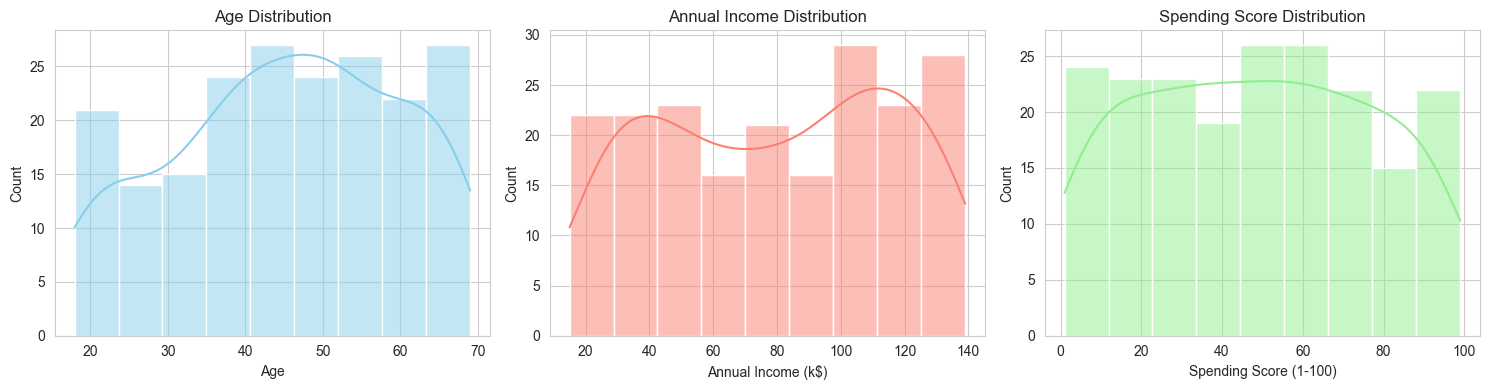

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Annual Income Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()


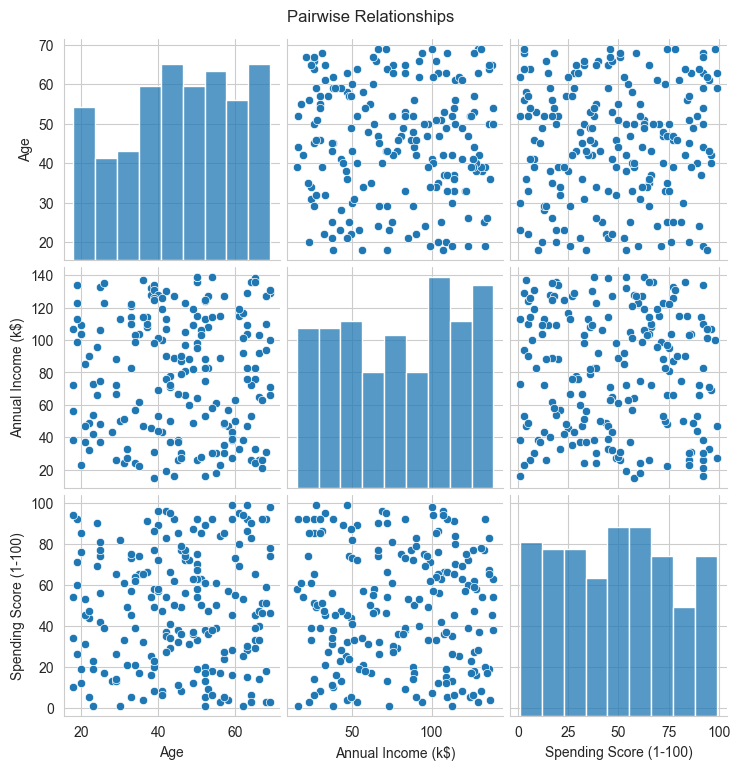

In [6]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()


## Phase 1 (SCALE): Standardization

Distance-based algorithms (like K-Means) use **Euclidean distance**. If one
feature has a much larger numeric range (e.g. Income in thousands vs.
Spending Score 1-100), it will dominate the distance calculation and distort
the clusters.

**Fix:** Use `StandardScaler` to transform every feature to have:
- Mean = 0
- Standard Deviation = 1

Formula:  `z = (x - mean) / std_dev`


In [7]:
# Select numeric features for clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)
X_scaled_df.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,2.000000e+02,2.000000e+02,2.000000e+02
mean,-2.042810e-16,1.598721e-16,4.884981e-17
std,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.882711e+00,-1.744170e+00,-1.665183e+00
25%,-7.338801e-01,-8.801846e-01,-8.298659e-01
50%,3.772281e-02,9.179840e-02,-1.213408e-02
75%,7.921790e-01,9.017843e-01,8.671474e-01
max,1.615222e+00,1.603772e+00,1.781600e+00


## Phase 2 (COMPRESS): Principal Component Analysis (PCA)

Real-world datasets often have 20+ features ("Curse of Dimensionality"),
which makes distances meaningless. PCA finds the directions (Principal
Components) of **maximum variance** and projects the data onto fewer
dimensions while preserving most of the information.

We check the **cumulative explained variance** to decide how many components
to keep (commonly aiming for ~95%, but for visualization we often use 2).


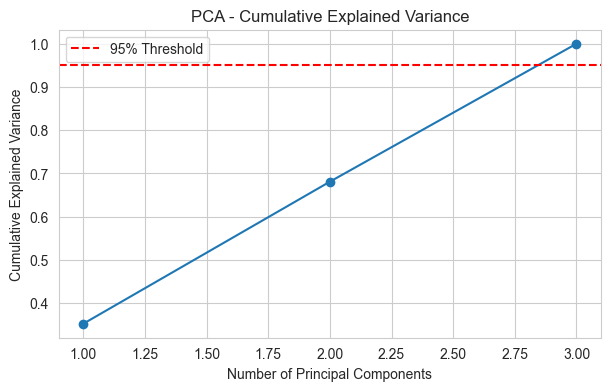

In [8]:
pca_full = PCA().fit(X_scaled)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),
         np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.show()


In [9]:
# Reduce to 2 components for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())


Explained variance ratio: [0.35244715 0.3285213 ]
Total variance retained: 0.680968444874571


## Phase 3: Finding the Optimal Number of Clusters (K)

K-Means cannot tell us how many clusters exist - we must decide K ourselves.
We use **two diagnostic gatekeepers**:

### Gatekeeper 1: The Elbow Method
- Calculates **WCSS** (Within-Cluster Sum of Squares) for different K values.
- We look for the "elbow" - the point where WCSS stops decreasing sharply.

### Gatekeeper 2: The Silhouette Score
- Measures how well-separated and cohesive the clusters are.
- Score close to **+1** = great clustering. Score close to **0** = overlapping clusters.


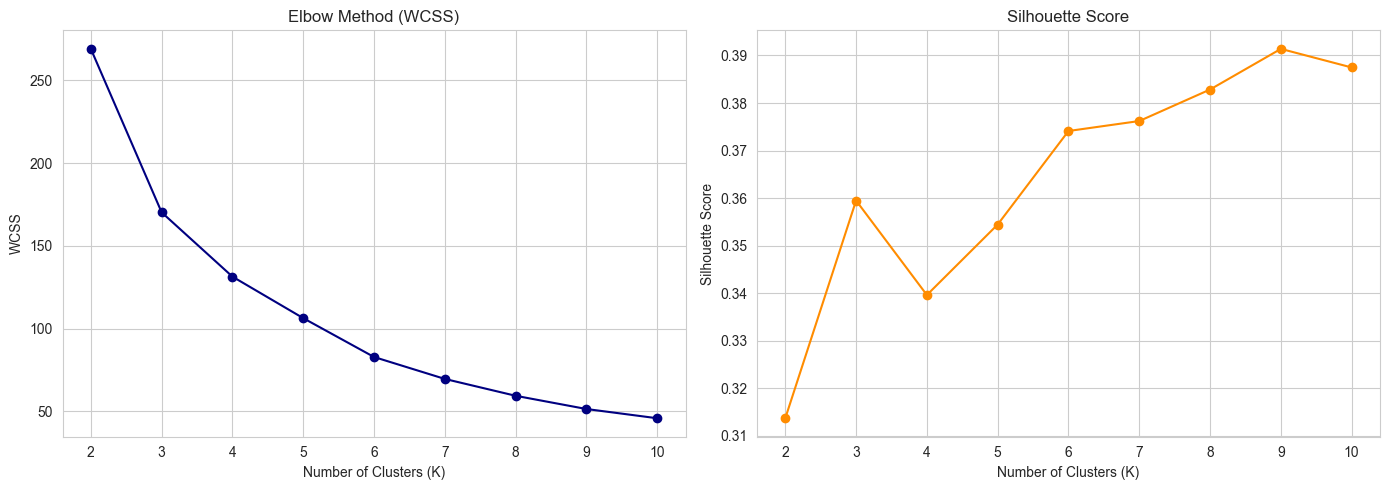

K=2: Silhouette Score = 0.3137
K=3: Silhouette Score = 0.3595
K=4: Silhouette Score = 0.3396
K=5: Silhouette Score = 0.3545
K=6: Silhouette Score = 0.3741
K=7: Silhouette Score = 0.3762
K=8: Silhouette Score = 0.3828
K=9: Silhouette Score = 0.3914
K=10: Silhouette Score = 0.3875


In [10]:
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_pca, labels))

# Plot Elbow Method
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), wcss, marker='o', color='navy')
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')

axes[1].plot(list(K_range), silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouette_scores):
    print(f"K={k}: Silhouette Score = {s:.4f}")


**Interpretation:**
Look at the Elbow plot for the "bend" in the curve, and pick the K that also
gives a high Silhouette Score. For the Mall Customers dataset, **K = 5** is a
commonly chosen value (you can confirm this from the printed scores above).

> Edit the `optimal_k` variable below based on YOUR results.


## Phase 3 (CLUSTER): Apply K-Means with Optimal K

In [11]:
optimal_k = 5  # <-- change this based on your Elbow/Silhouette results

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

df['Cluster'] = cluster_labels
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,41,100,7,3
1,2,Female,69,71,46,1
2,3,Female,28,43,13,2
3,4,Female,66,92,40,4
4,5,Male,25,106,42,3


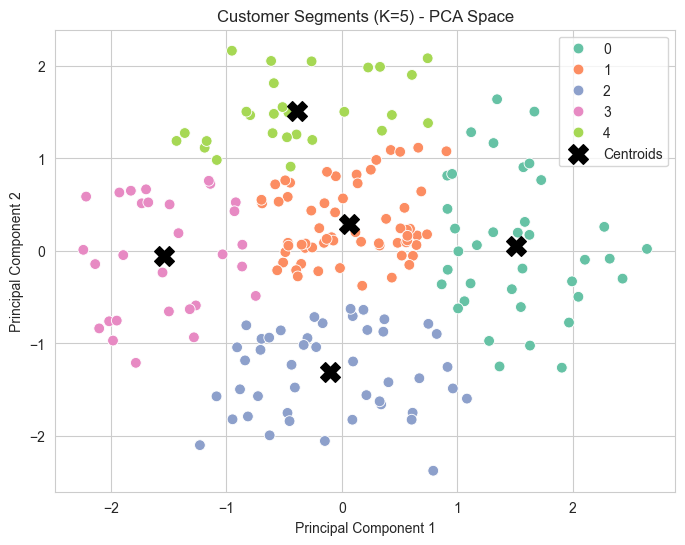

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=cluster_labels, palette='Set2', s=60)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='black', marker='X', s=200, label='Centroids')
plt.title(f'Customer Segments (K={optimal_k}) - PCA Space')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


## Phase 4 (TRANSLATE): Reverse-Engineering the Centroids

The cluster centroids are in PCA space and don't mean anything to a business
team. We reconstruct the original (human-readable) feature values for each
cluster using `inverse_transform`.


In [13]:
# Inverse PCA -> inverse Scaling to get original units
centroids_scaled = pca.inverse_transform(kmeans.cluster_centers_)
centroids_original = scaler.inverse_transform(centroids_scaled)

centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df.index.name = 'Cluster'
centroids_df.round(1)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,57.3,49.8,76.3
1,49.1,85.3,49.1
2,30.2,50.0,48.1
3,33.3,109.8,19.8
4,59.2,124.0,39.2


In [14]:
# Average values per cluster (sanity check, computed directly from real data)
df.groupby('Cluster')[features].mean().round(1)


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,57.4,49.7,76.2
1,49.5,84.1,47.7
2,30.6,48.8,46.7
3,31.6,115.3,26.0
4,59.4,123.3,38.4


## Building Business Personas

Now we translate the numeric clusters into actionable **marketing personas**.
Look at the average Age, Income, and Spending Score for each cluster (table
above) and assign a meaningful label + recommended business action.

Example persona table (edit based on YOUR actual cluster averages):

| Cluster | Persona Name              | Profile                              | Recommended Action |
|---------|----------------------------|---------------------------------------|----------------------|
| 0       | The Affluent Conservatives | High income, low spending score        | High-touch support, loyalty programs |
| 1       | The High-Value Trendsetters| High income, high spending score       | Exclusive perks, early access |
| 2       | The Budget Explorers       | Low income, high spending score        | Influencer campaigns, BNPL |
| 3       | The Conservative Minimizers| Low income, low spending score         | Discounts, basic utility |
| 4       | The Balanced Majority       | Medium income, medium spending score   | Standard marketing |


In [15]:
# Map cluster numbers to persona names (UPDATE based on your actual results)
persona_map = {
    0: 'The Affluent Conservatives',
    1: 'The High-Value Trendsetters',
    2: 'The Budget Explorers',
    3: 'The Conservative Minimizers',
    4: 'The Balanced Majority'
}

df['Persona'] = df['Cluster'].map(persona_map)
df[['CustomerID','Age','Annual Income (k$)','Spending Score (1-100)','Cluster','Persona']].head(10)


,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Cluster,Persona
0,1,41,100,7,3,The Conservative Minimizers
1,2,69,71,46,1,The High-Value Trendsetters
2,3,28,43,13,2,The Budget Explorers
3,4,66,92,40,4,The Balanced Majority
4,5,25,106,42,3,The Conservative Minimizers
5,6,53,83,9,1,The High-Value Trendsetters
6,7,55,61,50,1,The High-Value Trendsetters
7,8,57,127,27,4,The Balanced Majority
8,9,37,108,66,1,The High-Value Trendsetters
9,10,52,124,5,4,The Balanced Majority


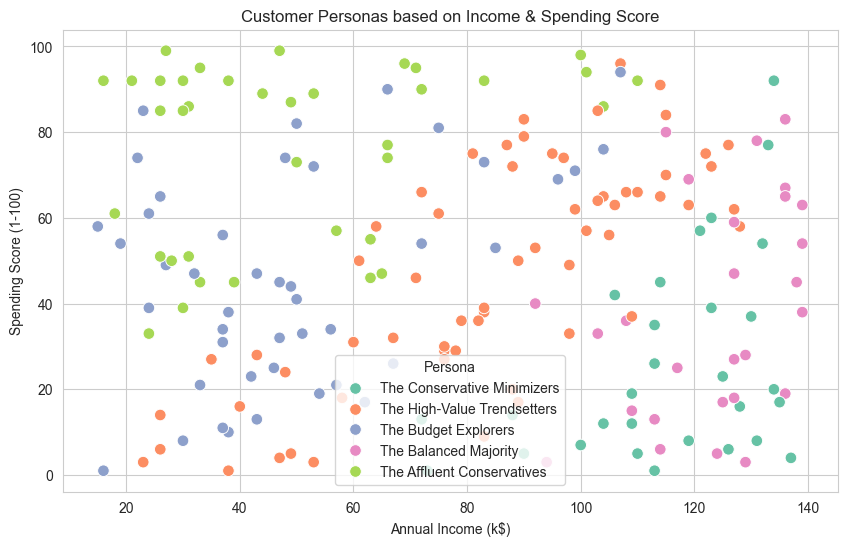

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Persona', palette='Set2', s=70)
plt.title('Customer Personas based on Income & Spending Score')
plt.show()


## Conclusion

In this project we:
1. **Scaled** our features using `StandardScaler` to remove scale bias.
2. **Compressed** the data using **PCA** to 2 dimensions for visualization.
3. **Clustered** the data using **K-Means**, mathematically validating our
   choice of K with the **Elbow Method** and **Silhouette Score**.
4. **Translated** the abstract clusters back into real-world units and
   built actionable **business personas**.

### Next Steps / Extensions
- Try this on a real dataset with 20+ columns (use full PCA pipeline → 95% variance).
- Visualize PCA components in 3D using `mpl_toolkits.mplot3d`.
- Try other clustering algorithms (DBSCAN, Hierarchical Clustering) and compare.
